# Training

In [1]:
# Imports for Training #

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, ReLU, MaxPool2D, BatchNormalization, Flatten, Dense
from tensorflow.keras.models import Model

I0000 00:00:1777021014.094698    6222 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Constants #

GAUSSIAN_X = 48
GAUSSIAN_Y = 48

MIN_OFFSET_X = -4
MAX_OFFSET_X = 4

MIN_OFFSET_Y = -4
MAX_OFFSET_Y = 4

MIN_STD_X = 5
MAX_STD_X = 11

MIN_STD_Y = 5
MAX_STD_Y = 11

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.2
MAX_INTENSITY = 0.8

# params: [center_x, center_y, std_x, std_y, sin2theta, cos2theta, intensity]
scaling_arr = np.array([48.0, 48.0, 24.0, 24.0, 1.0, 1.0, 1.0], dtype=np.float32)

SEED = 0
rng = np.random.default_rng(SEED)

In [4]:
# Generate Gaussian Functions #

def img_gen(rng: np.random.Generator = rng) -> tuple:

    center_x = GAUSSIAN_X / 2 + rng.uniform(MIN_OFFSET_X, MAX_OFFSET_X)
    center_y = GAUSSIAN_Y / 2 + rng.uniform(MIN_OFFSET_Y, MAX_OFFSET_Y)

    std_x = rng.uniform(MIN_STD_X, MAX_STD_X)
    std_y = rng.uniform(MIN_STD_Y, MAX_STD_Y)
    theta = rng.uniform(MIN_THETA, MAX_THETA)

    intensity = MIN_INTENSITY + rng.random() * (MAX_INTENSITY - MIN_INTENSITY)

    shape_params = np.array([center_x, center_y, std_x, std_y, theta])
    gaussian = np.array(gaussian_gen(*shape_params))
    gaussian = gaussian * intensity * 255
    gaussian = gaussian.astype(np.uint8)

    # params: [cx, cy, sx, sy, sin(2*theta), cos(2*theta), intensity]
    params = np.array([center_x, center_y, std_x, std_y, np.sin(2*theta), np.cos(2*theta), intensity])
    return (gaussian, params)

X, Y = np.meshgrid(
    np.arange(GAUSSIAN_X),
    np.arange(GAUSSIAN_Y)
)
def gaussian_gen(center_x: float, center_y: float, std_x: float, std_y: float, theta: float, X=X, Y=Y) -> np.ndarray:
    
    cos_theta_sqrd = np.power(np.cos(theta),2)
    sin_theta_sqrd = np.power(np.sin(theta),2)
    sin_cos_theta = np.sin(theta) * np.cos(theta)

    std_x_sqrd = np.power(std_x, 2)
    std_y_sqrd = np.power(std_y, 2)

    a = (cos_theta_sqrd) / (2 * std_x_sqrd) + (sin_theta_sqrd) / (2 * std_y_sqrd)
    b = -1 * (sin_cos_theta) / (2 * std_x_sqrd) + (sin_cos_theta) / (2 * std_y_sqrd)
    c = (sin_theta_sqrd) / (2 * std_x_sqrd) + (cos_theta_sqrd) / (2 * std_y_sqrd)

    gaussian = np.exp(-(a * (X - center_x)**2 + 2*b * (X - center_x) * (Y - center_y) + c * (Y - center_y)**2))

    return np.expand_dims(gaussian, -1)

def img_visualization_one(img: np.ndarray, params: np.ndarray) -> None:
    
    img = np.squeeze(img)
    rgb_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    if params is not None:
        # params: [cx, cy, sx, sy, sin(2t), cos(2t), intensity]
        theta = 0.5 * np.arctan2(params[4], params[5])
        print(
        f"[(c_x, c_y)]: ({params[0]:.2f}, {params[1]:.2f}) "
        f"[(s_x, s_y)]: ({params[2]:.2f}, {params[3]:.2f}) "
        f"[Theta]: {theta:.2f} "
        f"[I]: {params[6]:.2f} "
        )
    
    plt.imshow(rgb_image)
    plt.axis('off')

[(c_x, c_y)]: (24.85, 25.84) [(s_x, s_y)]: (8.26, 10.61) [Theta]: -0.58 [I]: 0.20 


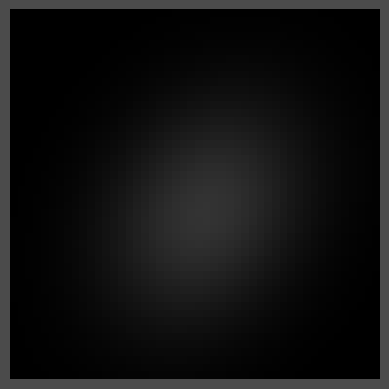

In [6]:
# Test Generate Functions #

img, params = img_gen()
img_visualization_one(img, params)

In [7]:
# Generate Training Dataset #
SAMPLE_COUNT = 10000
# TODO: look into using tf.data.Dataset.from_generator
# TODO: look into parallelizing

img_arr = np.empty((SAMPLE_COUNT, GAUSSIAN_Y, GAUSSIAN_X, 1), dtype=np.float32)
label_arr = np.empty((SAMPLE_COUNT, 7), dtype=np.float32)

for i in tqdm(range(SAMPLE_COUNT)):
    img, label = img_gen()
    img_arr[i] = img.astype(np.float32) / 256.0             # Normalize values [0, 1)
    label_arr[i] = label.astype(np.float32) / scaling_arr   # Normalize values using scaling array

print(f'[Images Shape]: {img_arr.shape}')
print(f'[Labels Shape]: {label_arr.shape}')

100%|██████████| 10000/10000 [00:00<00:00, 13963.40it/s]

[Images Shape]: (10000, 48, 48, 1)
[Labels Shape]: (10000, 7)


In [8]:
# Generate Validation Dataset for Training #
# TODO: look into using tf.data.Dataset.from_generator
# TODO: look into parallelizing
VAL_COUNT = 1000


img_arr_val = np.empty((VAL_COUNT, GAUSSIAN_Y, GAUSSIAN_X, 1), dtype=np.float32)
label_arr_val = np.empty((VAL_COUNT, 7), dtype=np.float32)

for i in tqdm(range(VAL_COUNT)):
    img, label = img_gen()
    img_arr_val[i] = img.astype(np.float32) / 256.0             # Normalize values [0, 1)
    label_arr_val[i] = label.astype(np.float32) / scaling_arr   # Normalize values using scaling array

print(f'[Images Shape]: {img_arr_val.shape}')
print(f'[Labels Shape]: {label_arr_val.shape}')

100%|██████████| 1000/1000 [00:00<00:00, 13428.82it/s]

[Images Shape]: (1000, 48, 48, 1)
[Labels Shape]: (1000, 7)


In [9]:
# Convert Data to TF Dataset #
BATCH_SIZE = 50

dataset = (
    tf.data.Dataset.from_tensor_slices(
        (img_arr, {'params': label_arr, 'reconstruction': img_arr})
    )
    .shuffle(SAMPLE_COUNT, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices(
        (img_arr_val, {'params': label_arr_val, 'reconstruction': img_arr_val})
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

W0000 00:00:1777021065.153655    6222 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [10]:
# Model Architecture #

input_layer = Input(shape=(GAUSSIAN_X, GAUSSIAN_Y, 1), name='InputLayer')

x = Conv2D(filters=4, kernel_size=3, strides=1, padding='valid',
           kernel_initializer='lecun_uniform', name='conv1')(input_layer)
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03, name='bn1')(x)
x = ReLU(name='relu1')(x)
x = MaxPool2D(pool_size=3, strides=3, name='pool1')(x)

x = Conv2D(filters=8, kernel_size=3, strides=1, padding='valid',
           kernel_initializer='lecun_uniform', name='conv2')(x)
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03, name='bn2')(x)
x = ReLU(name='relu2')(x)
x = MaxPool2D(pool_size=2, strides=2, name='pool2')(x)

x = Conv2D(filters=12, kernel_size=3, strides=1, padding='valid',
           kernel_initializer='lecun_uniform', name='conv3')(x)
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03, name='bn3')(x)
x = ReLU(name='relu3')(x)
x = MaxPool2D(pool_size=2, strides=2, name='pool3')(x)

x = Flatten(name='flatten')(x)
x = Dense(units=20, activation='relu', name='fc1')(x)

# Split head to constrain outputs:
x_center    = Dense(units=2, activation='linear',   name='center')(x)
x_std       = Dense(units=2, activation='softplus', name='std')(x)
x_theta     = Dense(units=2, activation='linear',   name='theta')(x)
x_intensity = Dense(units=1, activation='sigmoid',  name='intensity')(x)

x_p1        = tf.keras.layers.Concatenate(axis=-1, name='params_1')([x_center, x_std])
x_p2        = tf.keras.layers.Concatenate(axis=-1, name='params_2')([x_theta, x_intensity])
x_params    = tf.keras.layers.Concatenate(axis=-1, name='params')([x_p1, x_p2])  # 7-dim

gaussian_tf = Model(inputs=input_layer, outputs=x_params, name='gaussian')

In [11]:
# Tensorflow Functions #

scaling_tf = tf.constant(scaling_arr, dtype=tf.float32)
X_mesh_tf, Y_mesh_tf = tf.meshgrid(
    tf.range(GAUSSIAN_X, dtype=tf.float32),
    tf.range(GAUSSIAN_Y, dtype=tf.float32),
)
X_mesh_tf = X_mesh_tf[tf.newaxis, :, :, tf.newaxis]
Y_mesh_tf = Y_mesh_tf[tf.newaxis, :, :, tf.newaxis]
def gaussian_gen_tf(params_norm):
    # params_norm ordering: [cx, cy, sx, sy, sin2t, cos2t, intensity]
    params = params_norm * scaling_tf
    cx  = tf.reshape(params[:, 0], (-1, 1, 1, 1))
    cy  = tf.reshape(params[:, 1], (-1, 1, 1, 1))
    sx  = tf.reshape(params[:, 2], (-1, 1, 1, 1))
    sy  = tf.reshape(params[:, 3], (-1, 1, 1, 1))
    s2t = tf.reshape(params[:, 4], (-1, 1, 1, 1))
    c2t = tf.reshape(params[:, 5], (-1, 1, 1, 1))
    ity = tf.reshape(params[:, 6], (-1, 1, 1, 1))

    norm = tf.sqrt(tf.square(s2t) + tf.square(c2t) + 1e-6)
    s2t = s2t / norm
    c2t = c2t / norm

    cos_sqr = 0.5 * (1.0 + c2t)
    sin_sqr = 0.5 * (1.0 - c2t)
    sin_cos = 0.5 * s2t

    std_x_sqrd = tf.square(sx) + 1e-6
    std_y_sqrd = tf.square(sy) + 1e-6

    a = (cos_sqr) / (2.0 * std_x_sqrd) + (sin_sqr) / (2.0 * std_y_sqrd)
    b = -1.0 * (sin_cos) / (2.0 * std_x_sqrd) + (sin_cos) / (2.0 * std_y_sqrd)
    c = (sin_sqr) / (2.0 * std_x_sqrd) + (cos_sqr) / (2.0 * std_y_sqrd)

    dx = X_mesh_tf - cx
    dy = Y_mesh_tf - cy
    return ity * tf.exp(-(a * tf.square(dx) + 2.0 * b * dx * dy + c * tf.square(dy)))

x_reconstruction = tf.keras.layers.Lambda(gaussian_gen_tf, name='reconstruction')(gaussian_tf.output)
training_model = Model(
    inputs=gaussian_tf.input,
    outputs=[gaussian_tf.output, x_reconstruction],
    name='gaussian_training',
)

BG_WEIGHT = 0.05
def recon_loss(y_true, y_pred):
    W = y_true + BG_WEIGHT
    return tf.reduce_mean(tf.reduce_sum(W * tf.square(y_true - y_pred), axis=[1, 2, 3]))

CIRCLE_WEIGHT = 0.1
def supervised_params_loss(y_true, y_pred):
    diff = y_true - y_pred
    unambiguous = tf.stack([diff[:, 0], diff[:, 1], diff[:, 6]], axis=-1)
    mse_unambiguous = tf.reduce_mean(tf.reduce_sum(tf.square(unambiguous), axis=-1))

    s2t = y_pred[:, 4]
    c2t = y_pred[:, 5]
    circle = tf.reduce_mean(tf.square(tf.square(s2t) + tf.square(c2t) - 1.0))

    return mse_unambiguous + CIRCLE_WEIGHT * circle

In [12]:
# Train or Load #
TRAIN_MODEL = True
LOAD_MODEL = False

MODEL_NAME = '[Gaus]_[Generated]_[48].keras'
NUM_EPOCHS = 100

EARLY_STOPPING_PATIENCE = 10
MIN_DELTA = 1e-4

LOSS_WEIGHTS = {'params': 10.0, 'reconstruction': 1.0}

if TRAIN_MODEL and LOAD_MODEL:
    print("Are you sure you want to Train & Load ?")

elif TRAIN_MODEL:
    adam_optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-3,
        global_clipnorm=1.0,
    )
    training_model.compile(
        optimizer=adam_optimizer,
        loss={'params': supervised_params_loss, 'reconstruction': recon_loss},
        loss_weights=LOSS_WEIGHTS,
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        min_delta=MIN_DELTA,
        restore_best_weights=True,
        verbose=1,
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1,
    )

    history = training_model.fit(
        dataset,
        validation_data=val_dataset,
        epochs=NUM_EPOCHS,
        callbacks=[early_stop, reduce_lr],
        verbose=1,
    )

elif LOAD_MODEL:
    gaussian_tf = tf.keras.models.load_model(f'../Models/{MODEL_NAME}')

gaussian_tf.summary()

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 14.4430 - params_loss: 0.7898 - reconstruction_loss: 6.5451 - val_loss: 8.9465 - val_params_loss: 0.0902 - val_reconstruction_loss: 8.0444 - learning_rate: 0.0010
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.9301 - params_loss: 0.0165 - reconstruction_loss: 1.7649 - val_loss: 4.4811 - val_params_loss: 0.0485 - val_reconstruction_loss: 3.9962 - learning_rate: 0.0010
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.4594 - params_loss: 0.0110 - reconstruction_loss: 1.3492 - val_loss: 1.2097 - val_params_loss: 0.0128 - val_reconstruction_loss: 1.0821 - learning_rate: 0.0010
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.0774 - params_loss: 0.0083 - reconstruction_loss: 0.9946 - val_loss: 1.4960 - val_params_loss: 0.0072 - val_reconstruction_loss: 1.4241 - learning_rate: 0.0010
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9133 - params_loss: 0.0070 - reconstruc

Model: "gaussian"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ InputLayer          │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 46, 46, 4) │         40 │ InputLayer[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 46, 46, 4) │         16 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (ReLU)        │ (None, 46, 46, 4) │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 15, 15, 4) │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 13, 13, 8) │        296 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 13, 13, 8) │         32 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu2 (ReLU)        │ (None, 13, 13, 8) │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 6, 6, 8)   │          0 │ relu2[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, 4, 4, 12)  │        876 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 4, 4, 12)  │         48 │ conv3[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu3 (ReLU)        │ (None, 4, 4, 12)  │          0 │ bn3[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 2, 2, 12)  │          0 │ relu3[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 48)        │          0 │ pool3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 20)        │        980 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ center (Dense)      │ (None, 2)         │         42 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ std (Dense)         │ (None, 2)         │         42 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ theta (Dense)       │ (None, 2)         │         42 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ intensity (Dense)   │ (None, 1)         │         21 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ params_1            │ (None, 4)         │          0 │ center[0][0],     │
│ (Concatenate)       │                   │            │ std[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ params_2            │ (None, 3)         │          0 │ theta[0][0],    

 Total params: 2,435 (9.51 KB)

 Trainable params: 2,387 (9.32 KB)

 Non-trainable params: 48 (192.00 B)

In [ ]:
# Save Model #
SAVE_MODEL = True

if SAVE_MODEL:
    gaussian_tf.save(f'../Models/{MODEL_NAME}', include_optimizer=False)

In [15]:
# Predict on Validation Set #
predictions_tf = gaussian_tf.predict(img_arr_val)

print(f'[Validation Shape]: {img_arr_val.shape}')
print(f'[Prediction Shape]: {predictions_tf.shape}')

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[Validation Shape]: (1000, 48, 48, 1)
[Prediction Shape]: (1000, 7)


In [31]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)

label_real = label_arr_val[index] * scaling_arr
pred_real = predictions_tf[index] * scaling_arr

# Recover theta from (sin2t, cos2t) via arctan2. Principal value in [-pi/2, pi/2],
# which is the correct equivalence class for the ellipse symmetry.
theta_label = 0.5 * np.arctan2(label_real[4], label_real[5])
theta_pred  = 0.5 * np.arctan2(pred_real[4],  pred_real[5])

print(
    f"[Label]      [(c_x, c_y)]: ({label_real[0]:6.2f}, {label_real[1]:6.2f}) "
    f"[(s_x, s_y)]: ({label_real[2]:6.2f}, {label_real[3]:6.2f}) "
    f"[Theta]: {theta_label:.2f} "
    f"[I]: {label_real[6]:.2f} "
)

print(
    f"[Prediction] [(c_x, c_y)]: ({pred_real[0]:6.2f}, {pred_real[1]:6.2f}) "
    f"[(s_x, s_y)]: ({pred_real[2]:6.2f}, {pred_real[3]:6.2f}) "
    f"[Theta]: {theta_pred:.2f} "
    f"[I]: {pred_real[6]:.2f} "
)

[Label]      [(c_x, c_y)]: ( 27.42,  22.49) [(s_x, s_y)]: (  8.37,   7.82) [Theta]: -0.66 [I]: 0.51 
[Prediction] [(c_x, c_y)]: ( 27.26,  22.35) [(s_x, s_y)]: (  8.02,   8.25) [Theta]: 0.45 [I]: 0.51 


# HLS4ML

In [32]:
# HLS4ML Config #
import hls4ml
from hls4ml.utils import config_from_keras_model
from pprint import pprint

config = config_from_keras_model(gaussian_tf, granularity='name', backend='Vitis')

# config['Flows'] = ['vitis:fifo_depth_optimization']
# hls4ml.model.optimizer.get_optimizer('vitis:fifo_depth_optimization').configure(profiling_fifo_depth=100_000)

config['Model']['Strategy'] = 'Latency'
# config['Model']['PipelineStyle'] = 'pipeline'

config["Model"]["ReuseFactor"] = 8
for layer_cfg in config["LayerName"].values():
    if "ReuseFactor" in layer_cfg:
        layer_cfg["ReuseFactor"] = 8

pprint(config)

Keras v2 handler used for layer bn1
Keras v2 handler used for layer bn2
Keras v2 handler used for layer bn3
{'LayerName': {'InputLayer': {'Precision': {'result': 'auto'}, 'Trace': False},
               'bn1': {'Precision': {'bias': 'auto',
                                     'result': 'auto',
                                     'scale': 'auto'},
                       'ReuseFactor': 8,
                       'Trace': False},
               'bn2': {'Precision': {'bias': 'auto',
                                     'result': 'auto',
                                     'scale': 'auto'},
                       'ReuseFactor': 8,
                       'Trace': False},
               'bn3': {'Precision': {'bias': 'auto',
                                     'result': 'auto',
                                     'scale': 'auto'},
                       'ReuseFactor': 8,
                       'Trace': False},
               'center': {'Precision': {'accum': 'auto',
                       

In [33]:
# Compile & Predict #
hls_model = hls4ml.converters.convert_from_keras_model(
    gaussian_tf,
    hls_config=config,
    output_dir='../gaussian_hls4ml',
    io_type='io_stream',
    backend='Vitis',
    part='xcku035-fbva676-2-e',
    project_name='gaussian'
)

hls_model.compile()

predictions_hls4ml = hls_model.predict(img_arr_val).reshape(VAL_COUNT, 7)

print(f'[Validation Shape]: {img_arr_val.shape}')
print(f'[Prediction Shape]: {predictions_hls4ml.shape}')

Keras v2 handler used for layer bn1
Keras v2 handler used for layer bn2
Keras v2 handler used for layer bn3
[Validation Shape]: (1000, 48, 48, 1)
[Prediction Shape]: (1000, 7)


In [39]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)

label_real    = label_arr_val[index] * scaling_arr
pred_real_tf  = predictions_tf[index] * scaling_arr
pred_real_hls = predictions_hls4ml[index] * scaling_arr

theta_label    = 0.5 * np.arctan2(label_real[4],    label_real[5])
theta_pred_tf  = 0.5 * np.arctan2(pred_real_tf[4],  pred_real_tf[5])
theta_pred_hls = 0.5 * np.arctan2(pred_real_hls[4], pred_real_hls[5])

print(
    f"[Label]          [(c_x, c_y)]: ({label_real[0]:6.2f}, {label_real[1]:6.2f}) "
    f"[(s_x, s_y)]: ({label_real[2]:6.2f}, {label_real[3]:6.2f}) "
    f"[Theta]: {theta_label:.2f} "
    f"[I]: {label_real[6]:.2f} "
)

print(
    f"[Prediction TF]  [(c_x, c_y)]: ({pred_real_tf[0]:6.2f}, {pred_real_tf[1]:6.2f}) "
    f"[(s_x, s_y)]: ({pred_real_tf[2]:6.2f}, {pred_real_tf[3]:6.2f}) "
    f"[Theta]: {theta_pred_tf:.2f} "
    f"[I]: {pred_real_tf[6]:.2f} "
)

print(
    f"[Prediction HLS] [(c_x, c_y)]: ({pred_real_hls[0]:6.2f}, {pred_real_hls[1]:6.2f}) "
    f"[(s_x, s_y)]: ({pred_real_hls[2]:6.2f}, {pred_real_hls[3]:6.2f}) "
    f"[Theta]: {theta_pred_hls:.2f} "
    f"[I]: {pred_real_hls[6]:.2f} "
)

[Label]          [(c_x, c_y)]: ( 20.16,  20.06) [(s_x, s_y)]: (  5.72,   8.00) [Theta]: 0.45 [I]: 0.26 
[Prediction TF]  [(c_x, c_y)]: ( 22.11,  21.43) [(s_x, s_y)]: (  6.73,   8.08) [Theta]: 0.41 [I]: 0.23 
[Prediction HLS] [(c_x, c_y)]: ( 21.58,  20.91) [(s_x, s_y)]: (  6.91,   8.25) [Theta]: 0.41 [I]: 0.24 
